# SEIHRVD age-structured model, with NPIs

Previously, my model did not include transmission between different age groups. This meant that they could be created as separate objects, using a singular class. There was also only one $\beta$ per age group, representing transmission from someone in that age group, to someone else from that same group.

This is incorrect and so I have changed my code to better reflect this between-age-group mixing. This means we need a transmission matrix, that looks like this:

$$
\boldsymbol{\beta_v} = \begin{pmatrix}
\beta_v^{11} & \beta_v^{12} & \beta_v^{13} \\
\beta_v^{21} & \beta_v^{22} & \beta_v^{23} \\
\beta_v^{31} & \beta_v^{32} & \beta_v^{33}  \\
\end{pmatrix}
$$

Where $v \in \{ 1,2\}$ is the variant, and $\beta_v^{ba}$, where $b,a \in \{1,2,3\}$, is the transmission rate from age group $b$ to age group $a$. The values of these transmission rates - found in `modelParameters.ipynb` - have been found by using the NGM approach and approximating $R_0$ as 3, as well as using social contact matrices.

The code works as follows: we have a class `ODEsClass` which contains all 40 ODEs for the model, the function that reduces transmission in a lockdown (`betaFunc`), and all the age-dependent parameters. We can create three instances of this for the different age-groups, and we need to call all three of them in a new class to allow them to interact with eachother. This new class is called `simAllAges`.

I originally did this using `scipy.integrate.odeint`, which is what all my previous code used, but found some discontinuities in my graphs when the 'state' changed (*i.e.* a vaccine or new outbreak happens). So I tried using the newer `scipy.integrate.solve_ivp` and this seemed to work a lot better and so I will use this from here.

Given that vaccination of the adults begins when 40% of the elderly are vaccinated, and vaccination of the children begins when 40% of the adults are vaccinated, the ODE solver needs to continuously check for these events. `solve_ivp` is good for this, as it has an `events` parameter that you can give functions to check for given events. I therefore also need to sort the three different 'vaccine days', as well as when the second variant begins, in time order to determine which ODEs to use when. To do this, I have defined four different 'states' that can be passed into `ODEsClass.defineVars()` and return different lists of equations. The states are:

- 0 (no vaccine, 1 variant)  
- 1 (vaccine, 1 variant)  
- 2 (no vaccine, 2 variants)  
- 3 (vaccine, 2 variants)  
 
If both the vaccine and second variant happen in a simulation, then there are clearly two options of state progression:

$$ 0 \rightarrow 1 \rightarrow 3 $$

$$ 0 \rightarrow 2 \rightarrow 3 $$

Depending on if vaccineStart > outbreak2Start or vice versa.

I chose to pass these states in as a string of three numbers, *e.g.* `'001'`, where each number is the state that each age group is in (in the order: young, adult, elderly). So `001` means there is only 1 variant, but the elderly vaccine has begun.

 [ **Click here to skip to results**](#results)  

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi
import json
from types import SimpleNamespace
import math
import time


f = open("params.json", "r")
contents = f.read()
f.close()


params = json.loads(contents)

    
youngAgeGrp = params['0-19']
adultAgeGrp = params['20-64']
elderlyAgeGrp = params['65+']

In [4]:
class ODEsClass:
    
    def __init__(self, ageGrpParams, eta, lockdown1Start, lockdown1End, lockdown2Start, lockdown2End, outbreak2Start, days):
        self.params = SimpleNamespace(**ageGrpParams)
        self.params.eta1 = eta
        self.params.eta2 = 0.8*eta
        
        self.params.lockdown1Start = lockdown1Start
        self.params.lockdown1End = lockdown1End
        self.params.lockdown2Start = lockdown2Start
        self.params.lockdown2End = lockdown2End
        self.params.outbreak2Start = outbreak2Start
        self.params.days = days
        
        self.InitialVals = list(self.params.compartments.values()) # all 40 initial vals from modelParameters
        
    def betaFunc(self, time, var, ageGrp):
        beta = self.params.__dict__[var][ageGrp]
        
        if self.params.lockdown1Start < time <= self.params.lockdown1End:
            newBeta = (beta/self.params.compliance)*(1 + (self.params.compliance - 1)*np.exp(-(time - self.params.lockdown1Start)))
        elif self.params.lockdown2Start < time <= self.params.lockdown2End:
            newBeta = (beta/self.params.compliance)*(1 + (self.params.compliance - 1)*np.exp(-(time - self.params.lockdown2Start)))
        elif self.params.lockdown1End < time <= self.params.lockdown2Start:
            newBeta = beta + (beta*(1-self.params.compliance)/self.params.compliance)*np.exp(-self.params.easing*(time - self.params.lockdown1End))
        elif time > self.params.lockdown2End:
            newBeta = beta + (beta*(1-self.params.compliance)/self.params.compliance)*np.exp(-self.params.easing*(time - self.params.lockdown2End))
        else:
            newBeta = beta
        return newBeta
    
    # Defining all differential equations, and their RHS depending on the state (0,1,2,3)
    def defineVars(self, IVS, FOI1, FOI2, state):

        S_U = {0: self.params.omega1*IVS[30] - FOI1*IVS[0]/self.params.N,
               1: self.params.omega1*IVS[30]  - FOI1*IVS[0]/self.params.N - self.params.sigma*IVS[0],
               2: self.params.omega1*IVS[30] + self.params.omega2*IVS[32] - (FOI1+FOI2)*IVS[0]/self.params.N,
               3: self.params.omega1*IVS[30] + self.params.omega2*IVS[32] - (FOI1+FOI2)*IVS[0]/self.params.N - self.params.sigma*IVS[0] ,
              }[state]

        S1_V = {0: 0,
               1: self.params.sigma*(1-self.params.eta1)*IVS[0] + self.params.omega1*IVS[31] - FOI1*IVS[1]/self.params.N,
               2: 0,
               3: self.params.sigma*(1-self.params.eta1)*IVS[0] + self.params.omega1*IVS[31] + self.params.omega2*IVS[33] - (FOI1+FOI2)*IVS[1]/self.params.N,
              }[state]

        S1_VI = {0: 0,
               1: self.params.sigma*self.params.eta1*IVS[0],
               2: 0,
               3: self.params.sigma*self.params.eta1*IVS[0] - IVS[2],
               }[state]

        S2_V = {0: 0,
               1: 0,
               2: 0,
               3: (1-self.params.eta2)*IVS[2] + self.params.omega2*IVS[34] - FOI2*IVS[3]/self.params.N,
              }[state]

        S2_VI = {0: 0,
               1: 0,
               2: 0,
               3: self.params.eta2*IVS[2]
               }[state]

        E1_U = {0: FOI1*IVS[0]/self.params.N - self.params.epsilon1*IVS[5],
                1: FOI1*IVS[0]/self.params.N - self.params.epsilon1*IVS[5],
                2: FOI1*IVS[0]/self.params.N - self.params.epsilon1*IVS[5],
                3: FOI1*IVS[0]/self.params.N - self.params.epsilon1*IVS[5],
               }[state]

        E1_V = {0: 0,
                1: FOI1*IVS[1]/self.params.N -self.params.epsilon1*IVS[6],
                2: 0,
                3: FOI1*IVS[1]/self.params.N -self.params.epsilon1*IVS[6],
               }[state]

        E2_U = {0: 0,
               1: 0,
               2: FOI2*IVS[0]/self.params.N - self.params.epsilon2*IVS[7],
               3: FOI2*IVS[0]/self.params.N - self.params.epsilon2*IVS[7],
               }[state]


        E2_V = {0: 0,
                1: 0,
                2: 0,
                3: FOI2*IVS[1]/self.params.N -self.params.epsilon2*IVS[8],
               }[state]

        E2_VI = {0: 0,
                1: 0,
                2: 0,
                3: FOI2*IVS[3]/self.params.N -self.params.epsilon2*IVS[9],
                }[state]


        I1_SU = {0: self.params.epsilon1*self.params.d1*IVS[5] - self.params.gamma1prime*IVS[10],
                1: self.params.epsilon1*self.params.d1*IVS[5] - self.params.gamma1prime*IVS[10],
                2: self.params.epsilon1*self.params.d1*IVS[5] - self.params.gamma1prime*IVS[10],
                3: self.params.epsilon1*self.params.d1*IVS[5] - self.params.gamma1prime*IVS[10],
                }[state]

        I1_AU = {0: self.params.epsilon1*(1-self.params.d1)*IVS[5] - self.params.gamma1*IVS[11],
                1: self.params.epsilon1*(1-self.params.d1)*IVS[5] - self.params.gamma1*IVS[11],
                2: self.params.epsilon1*(1-self.params.d1)*IVS[5] - self.params.gamma1*IVS[11],
                3: self.params.epsilon1*(1-self.params.d1)*IVS[5] - self.params.gamma1*IVS[11],
                }[state]

        I1_RU = {0: self.params.gamma1prime*(1 - self.params.h1)*IVS[10] - self.params.delta1prime*IVS[12],
                1: self.params.gamma1prime*(1 - self.params.h1)*IVS[10] - self.params.delta1prime*IVS[12],
                2: self.params.gamma1prime*(1 - self.params.h1)*IVS[10] - self.params.delta1prime*IVS[12],
                3: self.params.gamma1prime*(1 - self.params.h1)*IVS[10] - self.params.delta1prime*IVS[12],
                }[state]

        I1_SV = {0: 0,
                1: self.params.epsilon1*self.params.d1*IVS[6] - self.params.gamma1prime*IVS[13],
                2: 0,
                3: self.params.epsilon1*self.params.d1*IVS[6] - self.params.gamma1prime*IVS[13],
                }[state]

        I1_AV = {0: 0,
                1: self.params.epsilon1*(1-self.params.d1)*IVS[6] - self.params.gamma1*IVS[14],
                2: 0,
                3: self.params.epsilon1*(1-self.params.d1)*IVS[6] - self.params.gamma1*IVS[14],
                }[state]

        I1_RV = {0: 0,
                1: self.params.gamma1prime*(1 - self.params.h1)*IVS[13] - self.params.delta1prime*IVS[15],
                2: 0,
                3: self.params.gamma1prime*(1 - self.params.h1)*IVS[13] - self.params.delta1prime*IVS[15],
                }[state]

        I2_SU = {0: 0,
                1: 0,
                2: self.params.epsilon2*self.params.d2*IVS[7] - self.params.gamma2prime*IVS[16],
                3: self.params.epsilon2*self.params.d2*IVS[7] - self.params.gamma2prime*IVS[16],
                }[state]

        I2_AU = {0: 0,
                1: 0,
                2: self.params.epsilon2*(1-self.params.d2)*IVS[7] - self.params.gamma2*IVS[17],
                3: self.params.epsilon2*(1-self.params.d2)*IVS[7] - self.params.gamma2*IVS[17],
                }[state]

        I2_RU = {0: 0,
                1: 0,
                2: self.params.gamma2prime*(1 - self.params.h2)*IVS[16] - self.params.delta2prime*IVS[18],
                3: self.params.gamma2prime*(1 - self.params.h2)*IVS[16] - self.params.delta2prime*IVS[18],
                }[state]

        I2_SV = {0: 0,
                1: 0,
                2: 0,
                3: self.params.epsilon2*self.params.d2*IVS[8] - self.params.gamma2prime*IVS[19],
                }[state]

        I2_AV = {0: 0,
                1: 0,
                2: 0,
                3: self.params.epsilon2*(1-self.params.d2)*IVS[8] - self.params.gamma2*IVS[20],
                }[state]

        I2_RV = {0: 0,
                1: 0,
                2: 0,
                3: self.params.gamma2prime*(1 - self.params.h2)*IVS[19] - self.params.delta2prime*IVS[21],
                }[state]

        I2_SVI = {0: 0,
                1: 0,
                2: 0,
                3: self.params.epsilon2*self.params.d2*IVS[9] - self.params.gamma2prime*IVS[22],
                 }[state]

        I2_AVI = {0: 0,
                1: 0,
                2: 0,
                3: self.params.epsilon2*(1-self.params.d2)*IVS[9] - self.params.gamma2*IVS[23],
                 }[state]

        I2_RVI = {0: 0,
                1: 0,
                2: 0,
                3: self.params.gamma2prime*(1 - self.params.h2)*IVS[22] - self.params.delta2prime*IVS[24],
                }[state]

        H1_U = {0: self.params.gamma1prime*self.params.h1*IVS[10] - self.params.delta1*IVS[25],
                1: self.params.gamma1prime*self.params.h1*IVS[10] - self.params.delta1*IVS[25],
                2: self.params.gamma1prime*self.params.h1*IVS[10] - self.params.delta1*IVS[25],
                3: self.params.gamma1prime*self.params.h1*IVS[10] - self.params.delta1*IVS[25],
               }[state]

        H1_V = {0: 0,
                1: self.params.gamma1prime*self.params.h1*IVS[13] - self.params.delta1*IVS[26],
                2: 0,
                3: self.params.gamma1prime*self.params.h1*IVS[13] - self.params.delta1*IVS[26],
               }[state]

        H2_U = {0: 0,
                1: 0,
                2: self.params.gamma2prime*self.params.h2*IVS[16] - self.params.delta2*IVS[27],
                3: self.params.gamma2prime*self.params.h2*IVS[16] - self.params.delta2*IVS[27],
               }[state]

        H2_V = {0: 0,
                1: 0,
                2: 0,
                3: self.params.gamma2prime*self.params.h2*IVS[19] - self.params.delta2*IVS[28],
               }[state]

        H2_VI = {0: 0,
                1: 0,
                2: 0,
                3: self.params.gamma2prime*self.params.h2*IVS[22] - self.params.delta2*IVS[29],
                }[state]

        R1_U = {0: self.params.delta1*(1-self.params.k1)*IVS[25] + self.params.delta1prime*IVS[12] + self.params.gamma1*IVS[11] - self.params.omega1*IVS[30],
                1: self.params.delta1*(1-self.params.k1)*IVS[25] + self.params.delta1prime*IVS[12] + self.params.gamma1*IVS[11] - self.params.omega1*IVS[30],
                2: self.params.delta1*(1-self.params.k1)*IVS[25] + self.params.delta1prime*IVS[12] + self.params.gamma1*IVS[11] - self.params.omega1*IVS[30],
                3: self.params.delta1*(1-self.params.k1)*IVS[25] + self.params.delta1prime*IVS[12] + self.params.gamma1*IVS[11] - self.params.omega1*IVS[30],
               }[state]

        R1_V = {0: 0,
                1: self.params.delta1*(1-self.params.k1)*IVS[26] + self.params.delta1prime*IVS[15] + self.params.gamma1*IVS[14] - self.params.omega1*IVS[31],
                2: 0,
                3: self.params.delta1*(1-self.params.k1)*IVS[26] + self.params.delta1prime*IVS[15] + self.params.gamma1*IVS[14] - self.params.omega1*IVS[31],
               }[state]

        R2_U = {0: 0,
                1: 0,
                2: self.params.delta2*(1-self.params.k2)*IVS[27] + self.params.delta2prime*IVS[18] + self.params.gamma2*IVS[17] - self.params.omega2*IVS[32],
                3: self.params.delta2*(1-self.params.k2)*IVS[27] + self.params.delta2prime*IVS[18] + self.params.gamma2*IVS[17] - self.params.omega2*IVS[32],
               }[state]

        R2_V = {0: 0,
                1: 0,
                2: 0,
                3: self.params.delta2*(1-self.params.k2)*IVS[28] + self.params.delta2prime*IVS[21] + self.params.gamma2*IVS[20] - self.params.omega2*IVS[33],
               }[state]

        R2_VI = {0: 0,
                1: 0,
                2: 0,
                3: self.params.delta2*(1-self.params.k2)*IVS[29] + self.params.delta2prime*IVS[24] + self.params.gamma2*IVS[23] - self.params.omega2*IVS[34],
                }[state]

        D1_U = {0: self.params.delta1*self.params.k1*IVS[25],
                1: self.params.delta1*self.params.k1*IVS[25],
                2: self.params.delta1*self.params.k1*IVS[25],
                3: self.params.delta1*self.params.k1*IVS[25],
               }[state]

        D1_V = {0: 0,
                1: self.params.delta1*self.params.k1*IVS[26],
                2: 0,
                3: self.params.delta1*self.params.k1*IVS[26],
               }[state]

        D2_U = {0: 0,
                1: 0,
                2: self.params.delta2*self.params.k2*IVS[27],
                3: self.params.delta2*self.params.k2*IVS[27],
               }[state]

        D2_V = {0: 0,
                1: 0,
                2: 0,
                3: self.params.delta2*self.params.k2*IVS[28],
               }[state]

        D2_VI = {0: 0,
                1: 0,
                2: 0,
                3: self.params.delta2*self.params.k2*IVS[29],
                }[state]
        
        Y = [S_U, S1_V, S1_VI, S2_V, S2_VI, E1_U, E1_V, E2_U, E2_V, E2_VI,I1_SU, I1_AU, I1_RU, I1_SV, I1_AV, I1_RV,I2_SU, I2_AU, I2_RU, I2_SV, I2_AV, I2_RV, I2_SVI, I2_AVI, I2_RVI,H1_U, H1_V, H2_U, H2_V, H2_VI,R1_U, R1_V, R2_U, R2_V, R2_VI,D1_U, D1_V, D2_U, D2_V, D2_VI]

        return Y 

In [5]:
class simAllAges:

    def __init__(self, eta, vaccineStart, lockdown1Start, lockdown1End, lockdown2Start, lockdown2End, outbreak2Start, days):

        self.youngSim = ODEsClass(youngAgeGrp, eta, lockdown1Start, lockdown1End, lockdown2Start, lockdown2End, outbreak2Start, days)
        self.adultSim = ODEsClass(adultAgeGrp, eta, lockdown1Start, lockdown1End, lockdown2Start, lockdown2End, outbreak2Start, days)
        self.elderlySim = ODEsClass(elderlyAgeGrp, eta, lockdown1Start, lockdown1End, lockdown2Start, lockdown2End, outbreak2Start, days)
        
        self.outputs = []
        
        self.events = {
            'elderlyVaccStart': None,
            'adultVaccStart': None,
            'youngVaccStart': None,
            'outbreak2Start': None,
            'simulationEnd': None
        }
        
        
        self.ageGroups = [self.youngSim, self.adultSim, self.elderlySim]
        

    def SEIHRVDmodel(self, time, IVS , state):  
        
        IVSlength = len(IVS)
        
        
        IVSyoung = IVS[0 : int(IVSlength/3)]
        IVSadult = IVS[int(IVSlength/3) : int(2 * IVSlength / 3)]
        IVSelderly = IVS[int(2 * IVSlength / 3) : IVSlength]
        
        ageIVS = [IVSyoung, IVSadult, IVSelderly]
        
        diffeqs = []
        
        for j, age in enumerate(self.ageGroups):
            FOI1 = 0
            FOI2 = 0
            for i in range(3):
                b1 = age.betaFunc(time, 'beta1', i)
                b2 = age.betaFunc(time, 'beta2', i)
                FOI1 += b1*(age.params.tau1*(ageIVS[i][11] + ageIVS[i][14]) + ageIVS[i][10] + ageIVS[i][12] + ageIVS[i][13] + ageIVS[i][15] + age.params.rho1*(ageIVS[i][25] + ageIVS[i][26]))
                FOI2 += b2*(age.params.tau2*(ageIVS[i][17] + ageIVS[i][20] + ageIVS[i][23]) + ageIVS[i][16] + ageIVS[i][18] + ageIVS[i][19] + ageIVS[i][21] + ageIVS[i][22] + ageIVS[i][24] + age.params.rho2*(ageIVS[i][27] + ageIVS[i][28] + ageIVS[i][29]))

            
            diffeqs.append(age.defineVars(ageIVS[j], FOI1, FOI2, int(state[j])))
            
            
        return list(np.array(diffeqs).ravel())
    
    
    def ODEsolver(self):
            
        ageInitialValues = []
        for age in self.ageGroups:
            ageInitialValues.append(age.InitialVals)
         
        # Defining 4x functions that hit zero when the given event should start, to be passed into solve_ivp as 'event functions'
        def elderlyVaccStart(t,y, state):
            return (t - vaccineStart) #hits zero when it is vaccineStart day
        
        elderlyVaccStart.terminal = True  # stops solver
        elderlyVaccStart.direction = 1
        elderlyVaccStart.name = "elderlyVaccine"
     
        def adultVaccStart(t, y, state):
            totalElderlyVaccinated = y[81] + y[82] + y[83] + y[84] + y[86] + y[88] + y[89] + y[93] + y[94] + y[95] + y[99] + y[100] + y[101] + y[102] + y[103] + y[104] + y[106] + y[108] + y[109] + y[111] + y[113] + y[114] + y[116] + y[118] + y[119]
            totalElderlyPop = self.elderlySim.params.N
            targetVaccinated = 0.4 * totalElderlyPop 
            
            return(totalElderlyVaccinated - targetVaccinated) # hits zero when the two are equal - telling solver to stop
        
        adultVaccStart.terminal = True  # stops solver
        adultVaccStart.direction = 1
        adultVaccStart.name = "adultVaccine"
        
        def youngVaccStart(t, y, state):
            totalAdultsVaccinated = y[41] + y[42] + y[43] + y[44] + y[46] + y[48] + y[49] + y[53] + y[54] + y[55] + y[59] + y[60] + y[61] + y[62] + y[63] + y[64] + y[66] + y[68] + y[69] + y[71] + y[73] + y[74] + y[76] + y[78] + y[79]
            totalAdultPop = self.adultSim.params.N
            targetVaccinated = 0.4 * totalAdultPop 
            
            return(totalAdultsVaccinated - targetVaccinated)
        
        youngVaccStart.terminal = True  # stops solver
        youngVaccStart.direction = 1
        youngVaccStart.name = "youngVaccine"
        
        def outbreak2Starting(t,y, state):
            return (t - outbreak2Start) #hits zero when it is outbreak2Start day
        
        outbreak2Starting.terminal = True  # stops solver
        outbreak2Starting.direction = 1
        outbreak2Starting.name = "outbreak2"
    
        valuesArray = []
        timeAtLastEvent = 0
        currentIVS = list(np.array(ageInitialValues).ravel())
        
        elderlyVaccineBit = 0b0
        adultVaccineBit = 0b0
        youngVaccineBit = 0b0
        outbreak2Bit = 0b0
        
        state = '000'  # states defined in markdown above
        
        activeEvents = [elderlyVaccStart, adultVaccStart, youngVaccStart, outbreak2Starting]
        while timeAtLastEvent < days:
            sol = spi.solve_ivp(
                self.SEIHRVDmodel, 
                (timeAtLastEvent, days), 
                currentIVS, 
                t_eval = np.arange(timeAtLastEvent, days,1),
                events = activeEvents,
                args = (state,) 
            )
            
            valuesArray.append(sol.y.T[1:])
            timeAtLastEvent = sol.t[-1]
            currentIVS = sol.y.T[-1]
            
            for i, eventName in enumerate(sol.t_events):
                if eventName.size > 0: # then this event was triggered
                    event = activeEvents[i].name
                    activeEvents.pop(i)
                    
                    if event == "elderlyVaccine":
                        self.events['elderlyVaccStart'] = sol.t_events[i][0]
                        elderlyVaccineBit = 0b1
                    if event == "adultVaccine":
                        self.events['adultVaccStart'] = sol.t_events[i][0]
                        adultVaccineBit = 0b1
                    if event == "youngVaccine":
                        self.events['youngVaccStart'] = sol.t_events[i][0]
                        youngVaccineBit = 0b1
                    if event == "outbreak2":
                        self.events['outbreak2Start'] = sol.t_events[i][0]
                        outbreak2Bit = 0b1
                        
                        currentIVS[7] += 100
                        currentIVS[16] += 100
                        currentIVS[17] += 100
                        currentIVS[47] += 100
                        currentIVS[56] += 100
                        currentIVS[57] += 100
                        currentIVS[87] += 100
                        currentIVS[96] += 100
                        currentIVS[97] += 100
                        
            
            youngState = int( (outbreak2Bit<<1) | (youngVaccineBit) )
            adultState = int( (outbreak2Bit<<1) | (adultVaccineBit) )
            elderlyState = int( (outbreak2Bit<<1) | (elderlyVaccineBit) )
        
            state = str(youngState) + str(adultState) + str(elderlyState)
            if sol.status == 0: break
        
        valuesYoung = []
        valuesAdult = []
        valuesElderly = []
        
        for v in valuesArray:
            valueLength = len(v[0])
            for l in v:
                valuesYoung.append(l[0 : int(valueLength / 3)])
                valuesAdult.append(l[int(valueLength / 3) : int(2 * valueLength / 3)])
                valuesElderly.append(l[int(2 * valueLength / 3) : valueLength])

        
        total_values = [ valuesYoung , valuesAdult, valuesElderly]

        # Getting the totals
        def totalAdderConsec(j, lower, upper):
            nonlocal total_values
            totalArray = []
            for i in range(len(total_values[j])): #iterate over every day
                total = 0
                for l in range(upper - lower + 1):
                    index = lower + l
                    total += total_values[j][i][index]
                totalArray.append(total)
                
            return totalArray
        
        def totalAdderIndices(j, indices):
            nonlocal total_values
            totalArray = []
            for i in range(len(total_values[j])):
                total = 0
                for l in indices:
                    total += total_values[j][i][l]
                totalArray.append(total)
                
            return totalArray
        
        self.outputs = []
        
        for i, age in enumerate(self.ageGroups):
        
            total_susceptible1 = totalAdderConsec(i, 0, 2)
            total_susceptible2 = totalAdderConsec(i, 3, 4)
            total_exposed1 = totalAdderConsec(i, 5, 6)
            total_exposed2 = totalAdderConsec(i, 7,9)
            total_infected1 = totalAdderConsec(i, 10, 15)
            total_infected2 = totalAdderConsec(i, 16, 24)
            total_hospitalised1 = totalAdderConsec(i, 25, 26)
            total_hospitalised2 = totalAdderConsec(i, 27, 29)
            total_recovered1 = totalAdderConsec(i, 30, 31)
            total_recovered2 = totalAdderConsec(i, 32, 34)
            total_dead1 = totalAdderConsec(i, 35, 36)
            total_dead2 = totalAdderConsec(i, 37, 39)
            total_vaccinated = totalAdderIndices(i, [1,2,3,4,6,8,9,13,14,15,19,20,21,22,23,24,26,28,29,31,33,34,36,38,39])
            self.totals = [total_susceptible1, total_susceptible2, total_exposed1, total_exposed2, total_infected1, total_infected2, total_hospitalised1, total_hospitalised2, total_recovered1, total_recovered2, total_dead1, total_dead2, total_vaccinated]
            self.vaccinated_immune = totalAdderIndices(i, [2,4,9,22,23,24,29,34,39])
            
            total_infectiousS1 = totalAdderIndices(i, [10, 13])
            dailyHosp1 = [age.params.gamma1prime*age.params.h1*(tis1) for tis1 in total_infectiousS1]
            
            total_infectiousS2 = totalAdderIndices(i, [16, 19, 22])
            dailyHosp2 = [age.params.gamma2prime*age.params.h2*(tis2) for tis2 in total_infectiousS2]
            
            self.dailyHosp = [dailyHosp1, dailyHosp2]
            
            self.outputs.append([self.totals, self.vaccinated_immune, self.dailyHosp])
        
        return(self.outputs)
    
    
    def outbreakEndResults(self, age): #returns final (total) hospitalisations, deaths, and vaccinations
        
        if len(self.outputs) == 0: 
            print('run sim first!')
            return
        
        self.totalHospitalised = math.ceil(sum(self.outputs[age][2][0] + self.outputs[age][2][1] ))
        self.totalDead = math.ceil(self.outputs[age][0][10][-1] + self.outputs[age][0][11][-1])
        self.totalVaccinated = math.ceil(self.outputs[age][0][12][-1])
        
        return(self.totalHospitalised, self.totalDead, self.totalVaccinated)
    
    def getVaccineDays(self):
        
        vaccDaysArray = []
        for ageGrp in ['elderlyVaccStart', 'adultVaccStart', 'youngVaccStart']:
            if self.events[ageGrp] is None:
                vaccDaysArray.append(0)
            else:
                vaccinationStart = math.floor(self.events[ageGrp])
                vaccDaysArray.append(vaccinationStart)
        
        return(vaccDaysArray)
        
        
    def printEndResults(self, age):
        results = self.outbreakEndResults(age)
        print("Over the course of the outbreak,", results[0], "people were hospitalised.")
        print("Over the course of the outbreak,", results[1], "people died.")
        print(results[2], "people have been vaccinated -", math.ceil(self.outputs[age][1][-1]), "successfully.") 

In [6]:
eta = 0.9
days = 365
lockdown1Start = 40
lockdown1End = 40 + 6*7
lockdown2Start = days+1
lockdown2End = days+1
outbreak2Start = 150
vaccineStart = 70


simulation = simAllAges(eta, vaccineStart, lockdown1Start, lockdown1End, lockdown2Start, lockdown2End, outbreak2Start, days)
Y, A, E = simulation.ODEsolver()
totalsY, vaccImmuneY, hospitalisationsY = Y
totalsA, vaccImmuneA, hospitalisationsA = A
totalsE, vaccImmuneE, hospitalisationsE = E

## Plotting <a id = 'results' ><a>

For those 0-19 years old:
Vaccination was started on day 102
Over the course of the outbreak, 813 people were hospitalised.
Over the course of the outbreak, 20 people died.
12661167 people have been vaccinated - 10903849 successfully.
--------------------------
For those 20-64 years old:
Vaccination was started on day 87
Over the course of the outbreak, 22062 people were hospitalised.
Over the course of the outbreak, 938 people died.
39269395 people have been vaccinated - 31937140 successfully.
--------------------------
For those aged 65+:
Vaccination was started on day 70
Over the course of the outbreak, 448432 people were hospitalised.
Over the course of the outbreak, 71300 people died.
12612097 people have been vaccinated - 10638343 successfully.


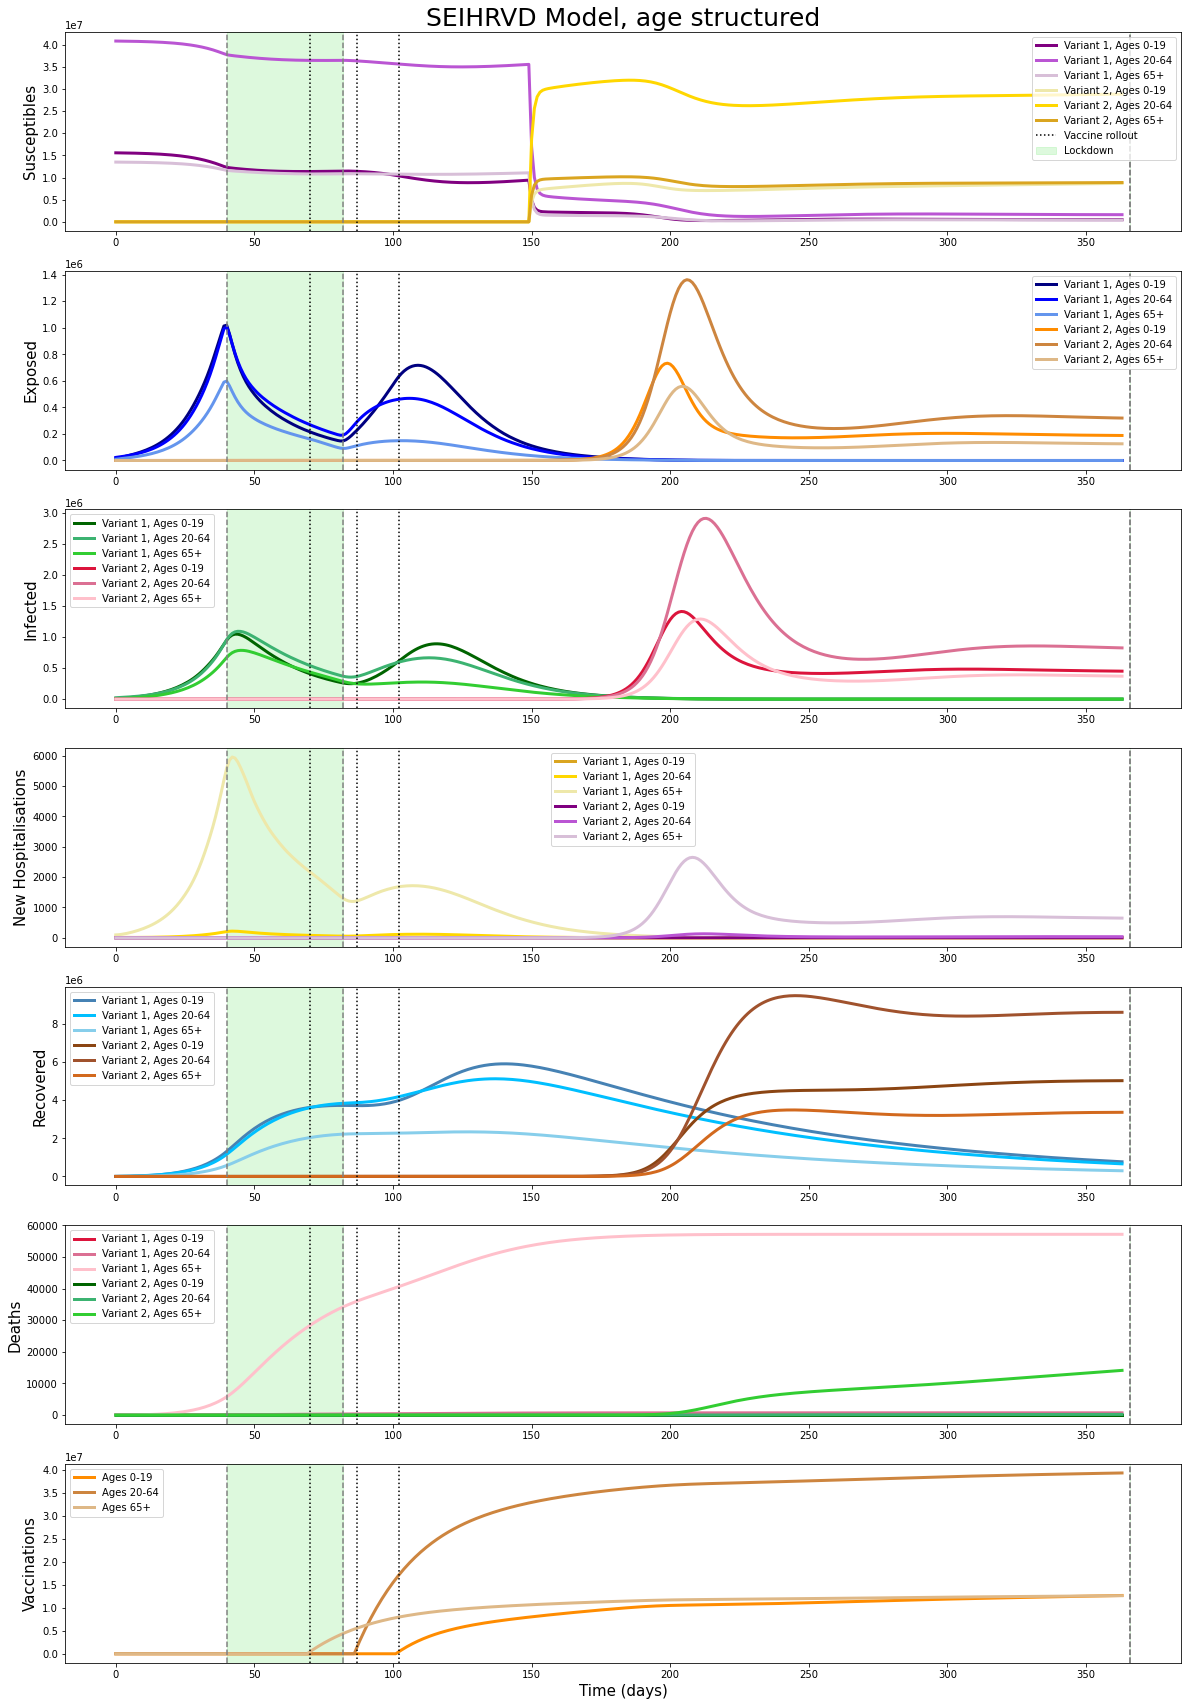

In [7]:
elderlyVaccStart, adultVaccStart, youngVaccStart = simulation.getVaccineDays()

print("For those 0-19 years old:")
print("Vaccination was started on day", youngVaccStart )
simulation.printEndResults(0)
print("--------------------------")
print("For those 20-64 years old:")
print("Vaccination was started on day", adultVaccStart )
simulation.printEndResults(1)
print("--------------------------")
print("For those aged 65+:")
print("Vaccination was started on day", elderlyVaccStart )
simulation.printEndResults(2)




# PLOTTING:
plt.figure(figsize=(20, 30))

plt.subplot(711) # SUSCEPTIBLES
plt.plot(totalsY[0], 'purple', linewidth = 3, label = 'Variant 1, Ages 0-19')
plt.plot(totalsA[0], 'mediumorchid', linewidth = 3, label = 'Variant 1, Ages 20-64')
plt.plot(totalsE[0], 'thistle', linewidth = 3, label = 'Variant 1, Ages 65+')
plt.plot(totalsY[1], 'palegoldenrod', linewidth=3, label = 'Variant 2, Ages 0-19')
plt.plot(totalsA[1], 'gold', linewidth = 3, label = 'Variant 2, Ages 20-64')
plt.plot(totalsE[1], 'goldenrod', linewidth = 3, label = 'Variant 2, Ages 65+')
plt.axvline(elderlyVaccStart, color = 'black', linestyle='dotted', label = 'Vaccine rollout')
plt.axvline(adultVaccStart, color = 'black', linestyle='dotted')
plt.axvline(youngVaccStart, color = 'black', linestyle='dotted')
plt.axvline(lockdown1Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown1End, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2End, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdown1Start, xmax=lockdown1End, alpha = 0.3, color = 'lightgreen', label = 'Lockdown')
plt.axvspan(xmin=lockdown2Start, xmax=lockdown2End, alpha = 0.3, color = 'lightgreen')
plt.title('SEIHRVD Model, age structured', fontsize=25)
plt.legend(loc=0)
plt.ylabel('Susceptibles', fontsize=15)

plt.subplot(712) # EXPOSED
plt.plot(totalsY[2], 'navy', linewidth=3, label = 'Variant 1, Ages 0-19')
plt.plot(totalsA[2], 'blue', linewidth = 3, label='Variant 1, Ages 20-64')
plt.plot(totalsE[2], 'cornflowerblue', linewidth = 3, label='Variant 1, Ages 65+')
plt.plot(totalsY[3], 'darkorange', linewidth = 3, label='Variant 2, Ages 0-19')
plt.plot(totalsA[3], 'peru', linewidth = 3, label='Variant 2, Ages 20-64')
plt.plot(totalsE[3], 'burlywood', linewidth = 3, label='Variant 2, Ages 65+')
plt.axvline(elderlyVaccStart, color = 'black', linestyle='dotted')
plt.axvline(adultVaccStart, color = 'black', linestyle='dotted')
plt.axvline(youngVaccStart, color = 'black', linestyle='dotted')
plt.axvline(lockdown1Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown1End, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2End, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdown1Start, xmax=lockdown1End, alpha = 0.3, color = 'lightgreen')
plt.axvspan(xmin=lockdown2Start, xmax=lockdown2End, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('Exposed', fontsize=15)

plt.subplot(713) # INFECTIOUS
plt.plot(totalsY[4], 'darkgreen', linewidth=3, label = 'Variant 1, Ages 0-19')
plt.plot(totalsA[4], 'mediumseagreen', linewidth = 3, label = 'Variant 1, Ages 20-64')
plt.plot(totalsE[4], 'limegreen', linewidth = 3, label = 'Variant 1, Ages 65+')
plt.plot(totalsY[5], 'crimson', linewidth=3, label = 'Variant 2, Ages 0-19')
plt.plot(totalsA[5], 'palevioletred', linewidth = 3, label='Variant 2, Ages 20-64')
plt.plot(totalsE[5], 'pink', linewidth = 3, label='Variant 2, Ages 65+')
plt.axvline(elderlyVaccStart, color = 'black', linestyle='dotted')
plt.axvline(adultVaccStart, color = 'black', linestyle='dotted')
plt.axvline(youngVaccStart, color = 'black', linestyle='dotted')
plt.axvline(lockdown1Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown1End, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2End, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdown1Start, xmax=lockdown1End, alpha = 0.3, color = 'lightgreen')
plt.axvspan(xmin=lockdown2Start, xmax=lockdown2End, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('Infected', fontsize=15)

plt.subplot(714) #HOSPITALISED
plt.plot(hospitalisationsY[0], 'goldenrod', linewidth=3, label = 'Variant 1, Ages 0-19')
plt.plot(hospitalisationsA[0], 'gold', linewidth = 3, label = 'Variant 1, Ages 20-64')
plt.plot(hospitalisationsE[0], 'palegoldenrod', linewidth = 3, label = 'Variant 1, Ages 65+')
plt.plot(hospitalisationsY[1], 'purple', linewidth = 3, label = 'Variant 2, Ages 0-19')
plt.plot(hospitalisationsA[1], 'mediumorchid', linewidth = 3, label = 'Variant 2, Ages 20-64')
plt.plot(hospitalisationsE[1], 'thistle', linewidth = 3, label = 'Variant 2, Ages 65+')
plt.axvline(elderlyVaccStart, color = 'black', linestyle='dotted')
plt.axvline(adultVaccStart, color = 'black', linestyle='dotted')
plt.axvline(youngVaccStart, color = 'black', linestyle='dotted')
plt.axvline(lockdown1Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown1End, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2End, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdown1Start, xmax=lockdown1End, alpha = 0.3, color = 'lightgreen')
plt.axvspan(xmin=lockdown2Start, xmax=lockdown2End, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('New Hospitalisations', fontsize=15)

plt.subplot(715) # RECOVERED
plt.plot(totalsY[8], 'steelblue', linewidth=3, label = 'Variant 1, Ages 0-19')
plt.plot(totalsA[8], 'deepskyblue', linewidth = 3, label = 'Variant 1, Ages 20-64')
plt.plot(totalsE[8], 'skyblue', linewidth = 3, label = 'Variant 1, Ages 65+')
plt.plot(totalsY[9], 'saddlebrown', linewidth=3, label = 'Variant 2, Ages 0-19')
plt.plot(totalsA[9], 'sienna', linewidth = 3, label = 'Variant 2, Ages 20-64')
plt.plot(totalsE[9], 'chocolate', linewidth = 3, label = 'Variant 2, Ages 65+')
plt.axvline(elderlyVaccStart, color = 'black', linestyle = 'dotted')
plt.axvline(adultVaccStart, color = 'black', linestyle='dotted')
plt.axvline(youngVaccStart, color = 'black', linestyle='dotted')
plt.axvline(lockdown1Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown1End, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2End, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdown1Start, xmax=lockdown1End, alpha = 0.3, color = 'lightgreen')
plt.axvspan(xmin=lockdown2Start, xmax=lockdown2End, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('Recovered', fontsize=15)

plt.subplot(716) # DEAD
plt.plot(totalsY[10], 'crimson', linewidth=3, label = 'Variant 1, Ages 0-19')
plt.plot(totalsA[10], 'palevioletred', linewidth = 3, label='Variant 1, Ages 20-64')
plt.plot(totalsE[10], 'pink', linewidth = 3, label='Variant 1, Ages 65+')
plt.plot(totalsY[11], 'darkgreen', linewidth=3, label = 'Variant 2, Ages 0-19')
plt.plot(totalsA[11], 'mediumseagreen', linewidth = 3, label = 'Variant 2, Ages 20-64')
plt.plot(totalsE[11], 'limegreen', linewidth = 3, label = 'Variant 2, Ages 65+')
plt.axvline(elderlyVaccStart, color = 'black', linestyle='dotted')
plt.axvline(adultVaccStart, color = 'black', linestyle='dotted')
plt.axvline(youngVaccStart, color = 'black', linestyle='dotted')
plt.axvline(lockdown1Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown1End, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2End, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdown1Start, xmax=lockdown1End, alpha = 0.3, color = 'lightgreen')
plt.axvspan(xmin=lockdown2Start, xmax=lockdown2End, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('Deaths', fontsize=15)

plt.subplot(717) # VACCINATED
plt.plot(totalsY[12], 'darkorange', linewidth = 3, label='Ages 0-19')
plt.plot(totalsA[12], 'peru', linewidth = 3, label='Ages 20-64')
plt.plot(totalsE[12], 'burlywood', linewidth = 3, label='Ages 65+')
plt.axvline(elderlyVaccStart, color = 'black', linestyle='dotted')
plt.axvline(adultVaccStart, color = 'black', linestyle='dotted')
plt.axvline(youngVaccStart, color = 'black', linestyle='dotted')
plt.axvline(lockdown1Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown1End, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2End, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdown1Start, xmax=lockdown1End, alpha = 0.3, color = 'lightgreen')
plt.axvspan(xmin=lockdown2Start, xmax=lockdown2End, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.xlabel('Time (days)', fontsize=15)
plt.ylabel('Vaccinations', fontsize = 15)

plt.show()